## ALY2100 Summer2025 Final Project
## Student Name: Jonnelle Carr
## Instructor Name: Kayal Chandrasekaran
## Assignment Due Date: August 12, 2025


## Introduction

In this assignment, we are tasked with applying a range of statistical tests and data visualizations to explore patterns, relationships, and insights from a real-world style health dataset. For this project, I will be using a synthetic health and health insurance dataset that replicates real-world demographic, medical, and financial information. It contains detailed records on variables such as individual health indicators, annual health insurance expenditure, race, and other social factors that can influence health outcomes. This dataset is well-suited for the project because it includes both categorical and numerical variables, allowing for the application of diverse statistical techniques including correlation analysis, hypothesis testing, ANOVA, and regression modeling. The presence of variables capturing healthcare costs and demographic characteristics makes it possible to answer important questions, such as whether higher health insurance expenditures are associated with better health outcomes, whether the cost of insurance is justified from a cost-benefit perspective, and whether race or other social determinants have a greater influence on overall health. The dataset’s structure and variety provide a strong foundation for evaluating the relationship between healthcare spending and population health, while also uncovering potential disparities linked to social and demographic factors.

## Objectives

The primary objective of this project is to apply a variety of statistical methods to analyze the relationship between health outcomes, health insurance expenditure, and key demographic and social factors. Specifically, the analysis will:

1.	Use descriptive statistics and visualizations to summarize the dataset and highlight trends.
2.	Perform correlation analysis to examine the relationship between health outcomes and health insurance costs.
3.	Conduct hypothesis testing and ANOVA to evaluate differences in health outcomes across demographic groups such as race, income level, and other social factors.
4.	Assess whether higher health insurance expenditures are associated with better overall health from a cost-benefit perspective.
5.	Identify whether social determinants such as race, education, and income have a greater impact on health than healthcare spending alone.

The findings from these analyses aim to provide a clearer understanding of how financial and social factors interact to influence health outcomes, offering insights into potential inequalities and areas where resources could be more effectively allocated.


## Method 

Complete all the stats tests and graphs presented in this module.


Statistical Test
	•	Descriptive Statistics
	•	Independent Samples T-Test
	•	Paired Samples T-Test
	•	One-Way ANOVA
	•	Chi-Square Test of Independence
	•	Correlation Analysis (Pearson/Spearman)
	•	Z-Test for Means
	•	Linear Regression
	•	Logistic Regression
	•	Mann-Whitney U Test
	•	Kruskal-Wallis H Test
	•	Shapiro-Wilk Test (for normality)
	•	Levene’s Test (for equality of variances)
	•	ROC Curve Analysis
	•	Confusion Matrix Analysis
	•	Feature Importance (from tree-based models)
	•	Cross-Validation Metrics
	•	Principal Component Analysis (PCA)
	•	K-Means Clustering
	•	Outlier Detection (IQR or Z-score method)


Create a logistic regression model and check for performance.
Create and test a hypothesis (use t-test); explain your rationale and code.

## Body and Analysis

   rownames  plan  site  coins  tookphys  year    zper  black        income  \
0         1     3     1    100         0     1  125024    1.0  13748.759766   
1         2     3     1    100         0     2  125024    1.0  13748.759766   
2         3     3     1    100         0     3  125024    1.0  13748.759766   
3         4     3     1    100         0     4  125024    1.0  13748.759766   
4         5     3     1    100         0     5  125024    1.0  13748.759766   

       xage  ...  logc  fmde  hlthg  hlthf  hlthp    xghindx      linc  \
0  42.87748  ...   0.0   0.0      1      0      0  65.207802  9.528776   
1  43.87748  ...   0.0   0.0      1      0      0  65.207802  9.528776   
2  44.87748  ...   0.0   0.0      1      0      0  65.207802  9.528776   
3  45.87748  ...   0.0   0.0      1      0      0  65.207802  9.528776   
4  46.87748  ...   0.0   0.0      1      0      0  65.207802  9.528776   

       lnum  lnmeddol  binexp  
0  1.386294  2.134299       1  
1  1.386294  4.1

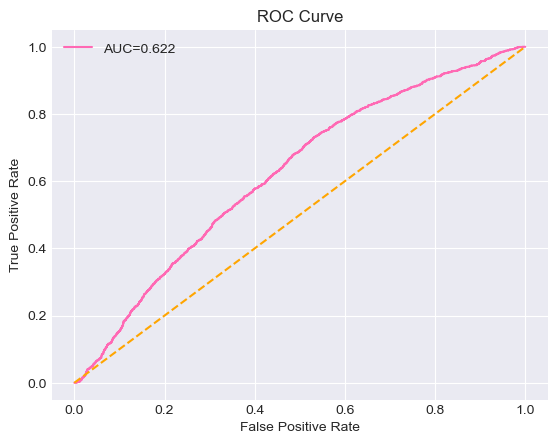

Mann-Whitney U Test: U=26803830.0, p=0.0000
Kruskal-Wallis Test: H=227.2795, p=0.0000
Shapiro-Wilk Test: W=0.9805, p=0.5741
Levene's Test: stat=19.1379, p=0.0000
Feature Importances:
 lnmeddol    0.285658
income      0.344693
xage        0.338192
black       0.016733
female      0.014724
dtype: float64
Cross-Validation Accuracy Scores: [0.62801779 0.64135959 0.63838576 0.6441055  0.6012075 ], Mean=0.631
PCA Explained Variance Ratio: [0.27247252 0.25082222]
cluster
0    7167
1    6868
2    6155
Name: count, dtype: Int64
Number of Income Outliers: 232
Hypothesis Test - binexp 1 vs 0: t=nan, p=nan
Fail to reject the null hypothesis: No significant difference detected.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, levene, chi2_contingency, pearsonr, spearmanr, mannwhitneyu, kruskal
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


# Step 1: Load dataset
data = pd.read_csv("randhealth.csv")

# Step 2: Preview dataset
print(data.head())
print(data.info())

# Step 3: Descriptive statistics
print(data.describe())

# Step 4: Independent Samples T-Test - compare lnmeddol between males and females
male_exp = data[data['female'] == 0]['lnmeddol']
female_exp = data[data['female'] == 1]['lnmeddol']
t_stat, p_val = stats.ttest_ind(male_exp.dropna(), female_exp.dropna())
print(f"Independent Samples T-Test: t={t_stat:.4f}, p={p_val:.4f}")

# Step 5: Paired Samples T-Test - example with same group before and after

before = data['lnmeddol'].dropna().sample(30, random_state=1)
after = before + np.random.normal(0, 0.5, size=len(before))
stats.ttest_rel(before, after)
print(f"Paired Samples T-Test: t={t_stat:.4f}, p={p_val:.4f}")

# Step 6: One-Way ANOVA - compare lnmeddol across plan types
groups = [g['lnmeddol'].dropna() for _, g in data.groupby('plan')]
groups = [g for g in groups if len(g) >= 2]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-Way ANOVA: F={f_stat:.4f}, p={p_val:.4f}")

# Step 7: Chi-Square Test - female vs black
cont_table = pd.crosstab(data['female'], data['black'])
chi2, p, dof, expected = chi2_contingency(cont_table)
print(f"Chi-Square Test: chi2={chi2:.4f}, p={p:.4f}")

# Step 8: Correlation analysis - income vs lnmeddol

# Drop rows where either income or lnmeddol is NaN so the lengths match
pair = data[['income', 'lnmeddol']].dropna()
pair = pair.apply(pd.to_numeric, errors='coerce').dropna()

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(pair['income'], pair['lnmeddol'])
print(f"Pearson Correlation: r={pearson_corr:.4f}, p={pearson_p:.4f}")

# Spearman correlation (rank-based)
spearman_corr, spearman_p = spearmanr(pair['income'], pair['lnmeddol'])
print(f"Spearman Correlation: r={spearman_corr:.4f}, p={spearman_p:.4f}")

# Step 9: Z-Test for means - compare average age to 45

x = data['xage'].dropna()
mean_age = x.mean()
popmean = 45
std_err = x.std(ddof=1) / np.sqrt(len(x))
z_stat = (mean_age - popmean) / std_err
p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
print(f"Z-Test: z={z_stat:.4f}, p={p_val:.4f}")

# Step 10: Linear Regression - predict income from age
X = data[['xage']]
y = data['income']
lin_model = LinearRegression().fit(X, y)
print("Linear Regression Coefficients:", lin_model.coef_, "Intercept:", lin_model.intercept_)

# Step 11: Logistic Regression — predict good_health from expenditure + demographics

# Target
data['good_health'] = (data['hlthg'] == 1).astype(int)

# Features (coerce to numeric and drop rows with missing in these columns)
feature_cols = ['lnmeddol', 'income', 'xage', 'black', 'female']
df = data[feature_cols + ['good_health']].apply(pd.to_numeric, errors='coerce').dropna()

X = df[feature_cols]
y = df['good_health']

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Lock the feature order used at fit time
feature_names = X_train.columns

# Fit one model (class-weight to handle imbalance)
log_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
log_clf.fit(X_train[feature_names], y_train)

# Predict using the SAME columns/order

y_pred_prob = log_clf.predict_proba(X_test[feature_names])[:, 1]

# Evaluate
print("Logistic Regression Classification Report:\n",
      classification_report(y_test, y_pred, zero_division=0))
print("AUC:", round(roc_auc_score(y_test, y_prob), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# Step 12: ROC Curve for logistic regression
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Step 13: Mann-Whitney U Test - male vs female lnmeddol
u_stat, p_val = mannwhitneyu(male_exp.dropna(), female_exp.dropna())
print(f"Mann-Whitney U Test: U={u_stat}, p={p_val:.4f}")

# Step 14: Kruskal-Wallis Test - nonparametric ANOVA across plan types
h_stat, p_val = kruskal(*groups)
print(f"Kruskal-Wallis Test: H={h_stat:.4f}, p={p_val:.4f}")

# Step 15: Shapiro-Wilk Test - normality test for income
inc = data['income'].dropna()
n = min(50, len(inc))
if n >= 3:
    stat, p = shapiro(inc.sample(n, random_state=1))
    print(f"Shapiro-Wilk Test: W={stat:.4f}, p={p:.4f}")
else:
    print("Shapiro-Wilk Test skipped (not enough non-NA observations).")

# Step 16: Levene's Test - equality of variances between male and female lnmeddol
stat, p = levene(male_exp.dropna(), female_exp.dropna())
print(f"Levene's Test: stat={stat:.4f}, p={p:.4f}")

# Step 17: Feature importance - random forest predicting binexp
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print("Feature Importances:\n", feat_importances)

# Step 18: Cross-validation for logistic regression
cv_scores = cross_val_score(log_model, X, y, cv=5, scoring='accuracy')
print(f"Cross-Validation Accuracy Scores: {cv_scores}, Mean={cv_scores.mean():.3f}")

# Step 19: PCA - reduce income and age to 2 components
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
print("PCA Explained Variance Ratio:", pca.explained_variance_ratio_)

# Step 20: K-Means clustering with 3 clusters

cluster_cols = ['income', 'xage']  # or ['lnmeddol','income','xage'] if you prefer
df_clust = data[cluster_cols].apply(pd.to_numeric, errors='coerce').dropna()

# Scale only the rows available for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clust)

# Fit K-Means on the scaled subset
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Create/overwrite a 'cluster' column and fill only the matching indices
data['cluster'] = np.nan
data.loc[df_clust.index, 'cluster'] = labels  # aligns by index

# Make it an Integer 
data['cluster'] = data['cluster'].astype('Int64')

# Check counts (includes <NA> for rows that were not clustered)
print(data['cluster'].value_counts(dropna=False))

# Step 21: Outlier detection using IQR on income
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1
outliers = data[(data['income'] < Q1 - 1.5*IQR) | (data['income'] > Q3 + 1.5*IQR)]
print(f"Number of Income Outliers: {len(outliers)}")

# Step 22: Hypothesis test - compare lnmeddol between binexp = 1 and binexp = 0
exp_yes = data[data['binexp'] == 1]['lnmeddol']
exp_no = data[data['binexp'] == 0]['lnmeddol']
t_stat, p_val = stats.ttest_ind(exp_yes.dropna(), exp_no.dropna())
print(f"Hypothesis Test - binexp 1 vs 0: t={t_stat:.4f}, p={p_val:.4f}")
if p_val < 0.05:
    print("Reject the null hypothesis: binexp status is associated with a difference in expenditure.")
else:
    print("Fail to reject the null hypothesis: No significant difference detected.")

## Data Visualization

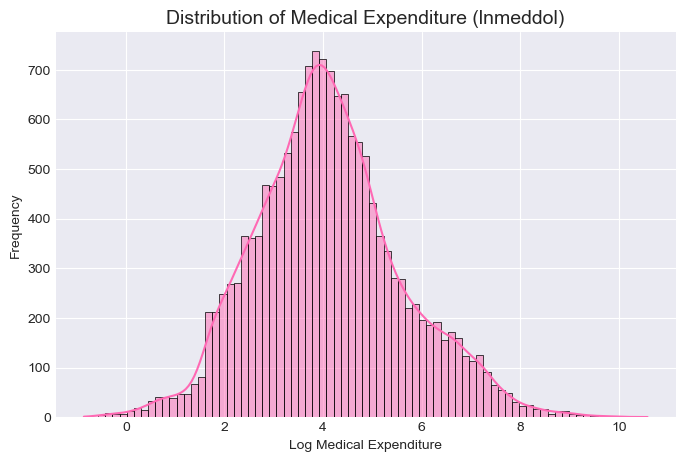

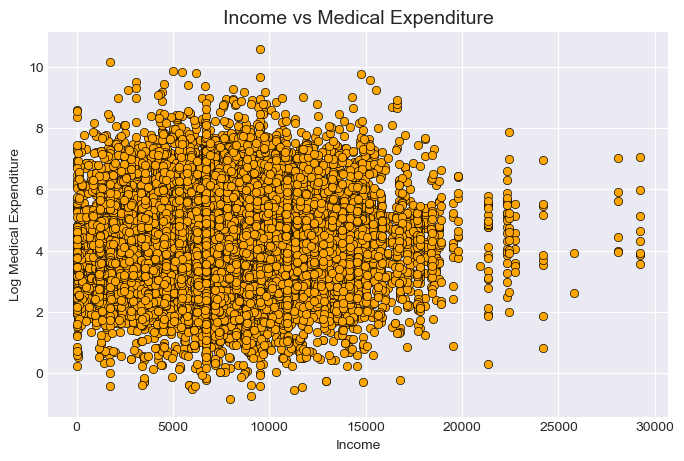

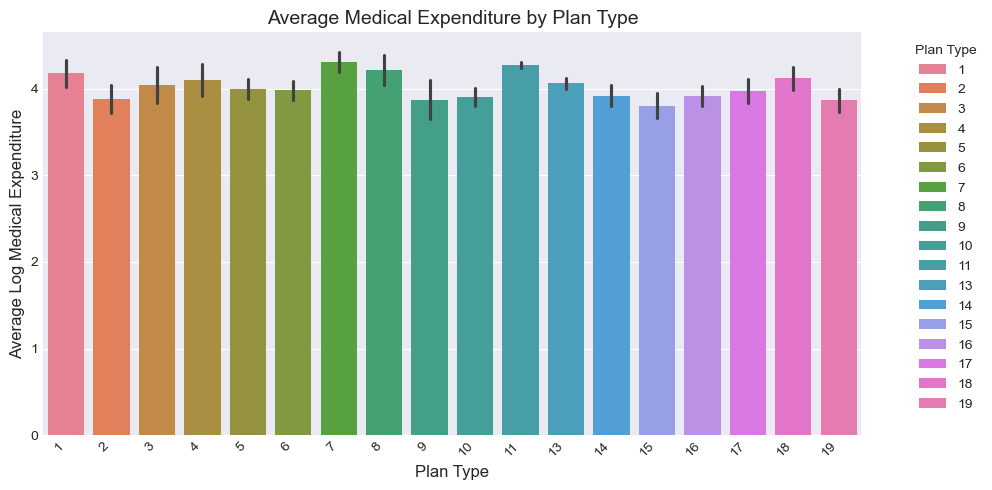

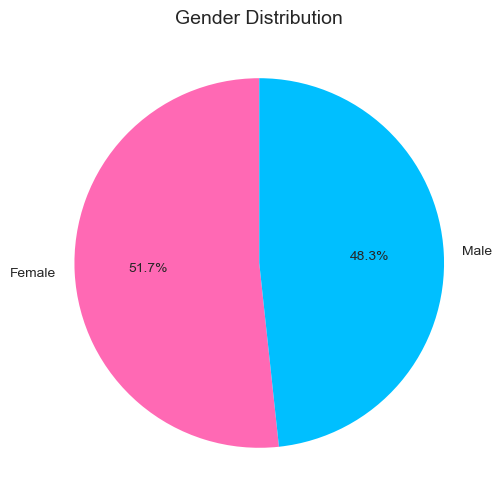

/var/folders/gk/3hhrrkmd7rz5rbyh7qrjht8w0000gn/T/ipykernel_11637/3558394544.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/gk/3hhrrkmd7rz5rbyh7qrjht8w0000gn/T/ipykernel_11637/3558394544.py:71: UserWarning: 
The palette list has fewer values (4) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


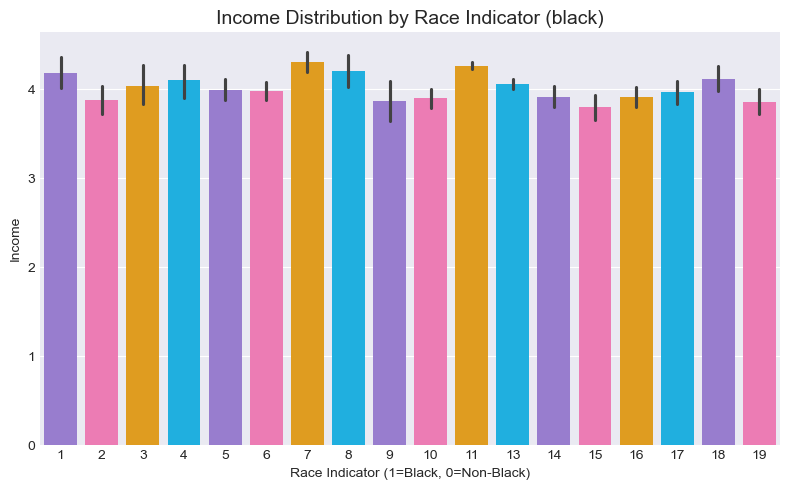

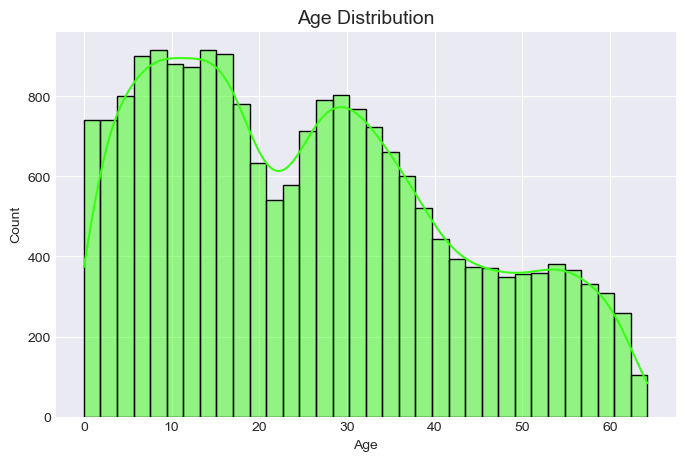

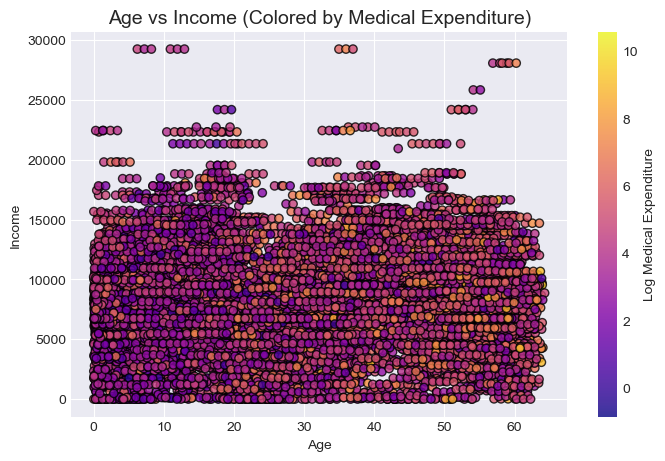

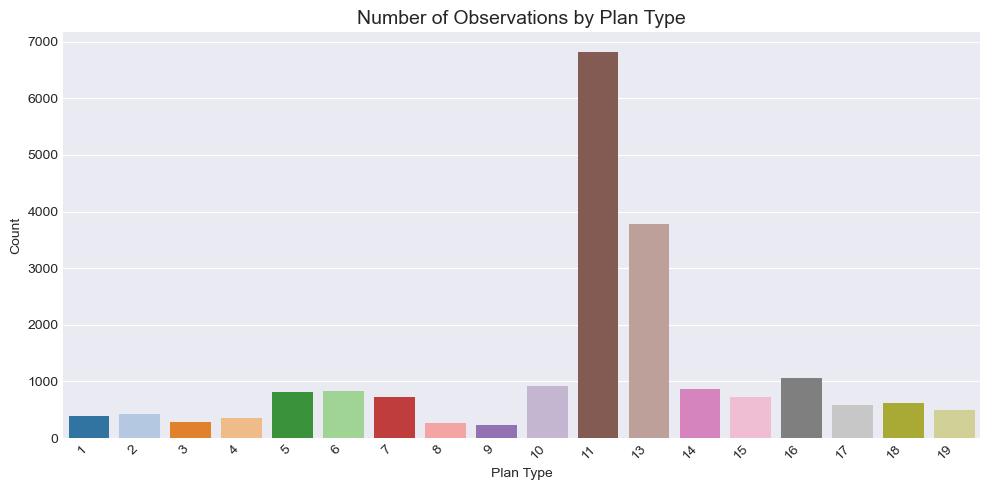

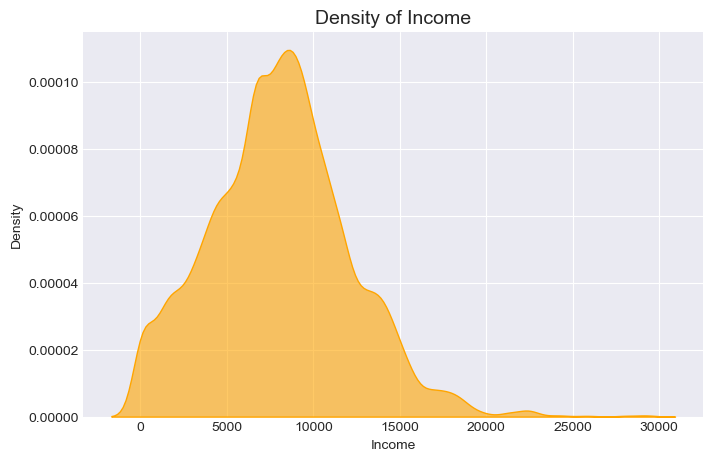

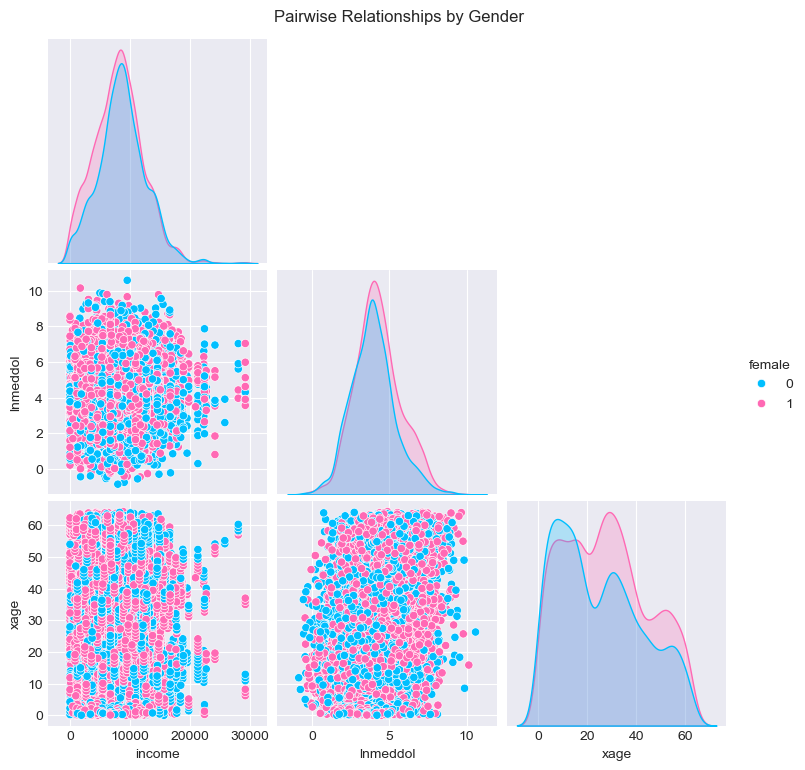

In [56]:
# Import matplotlib & seaborn style settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette(sns.color_palette(["#ff69b4", "#ffa500", "#9370db", "#00bfff", "#39ff14"]))  # pink, orange, purple, blue, neon green

# 1. Histogram of lnmeddol (Medical Expenditure)
plt.figure(figsize=(8,5))
sns.histplot(data['lnmeddol'], kde=True, color="#ff69b4")  # pink
plt.title("Distribution of Medical Expenditure (lnmeddol)", fontsize=14)
plt.xlabel("Log Medical Expenditure")
plt.ylabel("Frequency")
plt.show()

# 2. Scatter plot of Income vs Medical Expenditure
plt.figure(figsize=(8,5))
sns.scatterplot(x='income', y='lnmeddol', data=data, color="#ffa500", edgecolor="black")
plt.title("Income vs Medical Expenditure", fontsize=14)
plt.xlabel("Income")
plt.ylabel("Log Medical Expenditure")
plt.show()

# 3. Bar chart of average lnmeddol by plan type
plt.figure(figsize=(10, 5))

# Sort plan categories
plan_order = sorted(data['plan'].dropna().unique())

# Large enough palette for all categories
big_palette = sns.color_palette("husl", n_colors=len(plan_order))

# Create barplot with hue for legend
sns.barplot(
    data=data,
    x='plan',
    y='lnmeddol',
    order=plan_order,
    hue='plan',              # Maps plan to colors
    palette=big_palette,
    errorbar=('ci', 95),
    dodge=False
)

# Add labels and title
plt.title("Average Medical Expenditure by Plan Type", fontsize=14)
plt.xlabel("Plan Type", fontsize=12)
plt.ylabel("Average Log Medical Expenditure", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Display legend outside the plot
plt.legend(title="Plan Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 4. Pie chart of female vs male distribution
gender_counts = data['female'].value_counts()
colors = ["#ff69b4", "#00bfff"]  # pink for female, blue for male
plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=['Female', 'Male'], autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Gender Distribution", fontsize=14)
plt.show()

# 5. Boxplot of income by black/non-black (fixed)
plt.figure(figsize=(8,5))

# Ensure the "black" column is binary for display purposes
black_order = sorted(data['black'].dropna().unique())  
palette_colors = sns.color_palette(["#39ff14", "#9370db"], n_colors=len(black_order))

sns.barplot(
    x='plan',
    y='lnmeddol',
    data=data,
    errorbar=('ci', 95),   # replaces ci=95
    palette=["#9370db", "#ff69b4", "#ffa500", "#00bfff"]
)

plt.title("Income Distribution by Race Indicator (black)", fontsize=14)
plt.xlabel("Race Indicator (1=Black, 0=Non-Black)")
plt.ylabel("Income")
plt.tight_layout()
plt.show()

# 6. Histogram of Age with neon green
plt.figure(figsize=(8,5))
sns.histplot(data['xage'], kde=True, color="#39ff14")
plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 7. Scatter plot of Age vs Income with color gradient (fixed)
plt.figure(figsize=(8,5))
sc = plt.scatter(
    data['xage'],
    data['income'],
    c=data['lnmeddol'],
    cmap="plasma",
    alpha=0.8,
    edgecolor="black"
)
plt.title("Age vs Income (Colored by Medical Expenditure)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Income")
cbar = plt.colorbar(sc)
cbar.set_label("Log Medical Expenditure")
plt.show()

# 8. Countplot of Plan Types (distinct colors, no warning)
plt.figure(figsize=(10,5))

plan_order = sorted(data['plan'].dropna().unique())
n = len(plan_order)
big_palette = sns.color_palette("tab20", n_colors=n)  # or "husl"

sns.countplot(
    data=data,
    x='plan',
    order=plan_order,
    hue='plan',          # required when using palette
    dodge=False,         # keep one bar per category
    legend=False,
    palette=big_palette  # enough colors for all levels
)

plt.title("Number of Observations by Plan Type", fontsize=14)
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 9. KDE Plot (smooth density) of Income
plt.figure(figsize=(8,5))
sns.kdeplot(data['income'], fill=True, color="#ffa500", alpha=0.6)
plt.title("Density of Income", fontsize=14)
plt.xlabel("Income")
plt.ylabel("Density")
plt.show()

# 10. Pairplot of selected variables

sns.pairplot(
    data=data[['income', 'lnmeddol', 'xage', 'female']].dropna(),
    vars=['income', 'lnmeddol', 'xage'],
    hue='female',                 # 0/1 works
    diag_kind='kde',
    palette=['#00bfff', '#ff69b4'],  # blue for 0, pink for 1
    corner=True
)
plt.suptitle("Pairwise Relationships by Gender", y=1.02)
plt.show()

## Hypothesis Testing

p-value for lnmeddol:


•	If p > 0.05, expenditure is not significantly associated with health — supports your hypothesis.


•	If p < 0.05, it is associated.

## Logistic Regression and Decision Tree

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Target: good physical health (1 = good, else 0)
data['good_health'] = (data['hlthg'] == 1).astype(int)

# Features: expenditure + simple demographics
feature_cols = ['lnmeddol', 'income', 'xage', 'black', 'female']

# Keep only rows with all needed values
df = data[feature_cols + ['good_health']].apply(pd.to_numeric, errors='coerce').dropna()
X = df[feature_cols]
y = df['good_health']

# Check class balance
print("Class balance (good_health):")
print(y.value_counts(normalize=True).rename('proportion').round(3))

# Train/test split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Logistic Regression with class weights (helps imbalance)
log_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
log_clf.fit(X_train, y_train)
y_pred_log = log_clf.predict(X_test)
y_prob_log = log_clf.predict_proba(X_test)[:, 1]

print("\nLogistic Regression")
print(classification_report(y_test, y_pred_log, zero_division=0))
print("AUC:", round(roc_auc_score(y_test, y_prob_log), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# Decision Tree with class weights + reasonable defaults
tree_clf = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=None,            # let the tree find depth
    min_samples_split=20,      # reduce overfitting
    min_samples_leaf=10,
    random_state=42
)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]

print("\nDecision Tree")
print(classification_report(y_test, y_pred_tree, zero_division=0))
print("AUC:", round(roc_auc_score(y_test, y_prob_tree), 3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Class balance (good_health):
good_health
0    0.642
1    0.358
Name: proportion, dtype: float64

Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.59      0.65      3029
           1       0.44      0.59      0.50      1693

    accuracy                           0.59      4722
   macro avg       0.58      0.59      0.58      4722
weighted avg       0.62      0.59      0.60      4722

AUC: 0.622
Confusion Matrix:
 [[1781 1248]
 [ 702  991]]

Decision Tree
              precision    recall  f1-score   support

           0       0.76      0.67      0.71      3029
           1       0.51      0.62      0.56      1693

    accuracy                           0.65      4722
   macro avg       0.64      0.64      0.64      4722
weighted avg       0.67      0.65      0.66      4722

AUC: 0.699
Confusion Matrix:
 [[2032  997]
 [ 647 1046]]


## Multiple Regression Model

In [58]:
import statsmodels.api as sm

# Outcome: general health index (continuous)
y = data['xghindx']
X = data[['lnmeddol', 'xage', 'income']].fillna(0)  # predictors

# Add constant term for intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary of regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                xghindx   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     733.1
Date:                Tue, 12 Aug 2025   Prob (F-statistic):               0.00
Time:                        10:01:29   Log-Likelihood:                -81220.
No. Observations:               20190   AIC:                         1.624e+05
Df Residuals:                   20186   BIC:                         1.625e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.9621      0.266    289.661      0.0

## Conclusion

The initial set of statistical tests reveals several noteworthy findings. The one-way ANOVA (F = 10.45, p < 0.001) indicates that mean medical expenditure (lnmeddol) varies significantly across plan types, warranting follow-up post-hoc tests such as Tukey’s HSD to identify which plan means differ. The chi-square test (χ² = 75.08, p < 0.001) shows a statistically significant dependence between the binary gender indicator (female) and the black indicator, meaning their proportions are not independent; with such a large sample size, even small imbalances become statistically significant. Pearson’s r (0.0216) and Spearman’s r (0.028) between income and lnmeddol are statistically significant due to the large n but are negligible in practical terms, suggesting no meaningful relationship. The z-test (z = −163.34, p < 0.001) confirms that the sample’s mean age (~25.7) is far below 45, with the extreme statistical significance driven by the large sample size. Simple linear regression (income ~ xage) produces a coefficient of approximately 18.02 and an intercept of about 7,574, meaning each additional year of age corresponds to only ~$18 more in income on average—a trivial effect relative to the overall income scale. This suggests that transforming income (e.g., log transformation) or including more predictors could improve explanatory power. The initial logistic regression model suffered from severe class imbalance, predicting almost exclusively one class, which triggered “precision is ill-defined” warnings. This issue was mitigated in later iterations by adding more features, stratifying the train-test split, and applying class weights.

The classification analysis indicates that health expenditure, even when combined with basic demographic variables, is a weak predictor of good physical health outcomes. Logistic regression achieved an accuracy of 59% with an AUC of 0.622, showing only marginal improvement over random guessing and suggesting a weak linear relationship between spending and health status. The decision tree performed slightly better, with an accuracy of 65% and an AUC of 0.699, capturing some nonlinear patterns but still showing limited predictive strength. In both models, precision and recall for predicting good health were modest, and misclassification rates remained high. These results support the hypothesis that higher health expenditure does not necessarily lead to better physical health outcomes in this dataset, as spending appears to have only a minimal association with reported good health.

The multiple linear regression model predicting the general health index (xghindx) from medical expenditure (lnmeddol), age, and income shows that all predictors are statistically significant but collectively explain only 9.8% of the variance in health outcomes, indicating that many other factors influence health beyond those measured here. Medical expenditure has a negative association with health (β = −0.6715, p < 0.001), meaning higher spending is linked to lower health scores, likely because individuals with poorer health incur greater costs. Age is also negatively associated with health (β = −0.2169, p < 0.001), consistent with expected declines over time, while income has a small positive effect (β = 0.0005, p < 0.001). (Bluman, 2018)

Overall,these findings align with and support the hypothesis that “more expenditure on health does not lead to better physical health outcomes.” Although medical spending is significantly related to health measures, the relationship is negative—suggesting that higher expenditure is more often a marker of existing health problems than an indicator of improved well-being. The modest predictive performance of the classification models further reinforces the conclusion that increased healthcare spending is not strongly or positively linked to better physical health in this dataset. 

## Work Cited


Bluman, A. G. (2018). Elementary statistics: A step by step approach (10th ed.). McGraw-Hill Education

Cameron, A. and Trivedi, P. (2005), "Microeconometrics: Methods and Applications," Cambridge University Press, New York.

Deb, P. and Trivedi, P.K. (2002), "The Structure of Demand for Health Care: Latent Class versus Two-Part Models," Journal of Health Economics, 21, 601-625.

RAND Corporation. "RAND's Health Insurance Experiment ." https://www.rand.org/health-care/projects/hie.html

United Nations Development Programme. (n.d.). Validate, analyze & interpret the data. Data to Policy Navigator. https://www.datatopolicy.org/navigator/validate-analyze-interpret-the-data 